In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
data = pd.read_csv(r"D:\merged_flight_weather.csv")

In [7]:
def time_to_seconds(time_str):
    """Convert time in HHMMSS format to total seconds."""
    try:
        h, m, s = int(time_str[:2]), int(time_str[2:4]), int(time_str[4:])
        return h * 3600 + m * 60 + s
    except ValueError:
        return 0  # Handle invalid time strings

data['CRSDepTime'] = data['CRSDepTime'].astype(str).apply(time_to_seconds)

In [9]:
features = ['CRSArrTime', 'WindSpeedKmph', 'WindDirDegree', 'WeatherCode', 
            'precipMM', 'Visibilty', 'Pressure', 'Cloudcover', 'DewPointF', 
            'WindGustKmph', 'tempF', 'WindChillF', 'Humidity', 'Year', 
            'Quarter', 'Month', 'DayofMonth', 'CRSDepTime', 'DepDelayMinutes']
target = 'ArrDelayMinutes'

In [11]:
data = data.fillna(0)

In [13]:
X = data[features]
y = data[target]

In [15]:
lin_reg = LinearRegression()

In [17]:
lin_reg.fit(X, y)

LinearRegression()

In [19]:
y_pred = lin_reg.predict(X)

In [21]:
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

In [23]:
print(f"R² Score: {r2:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

R² Score: 0.92
Root Mean Squared Error: 11.57


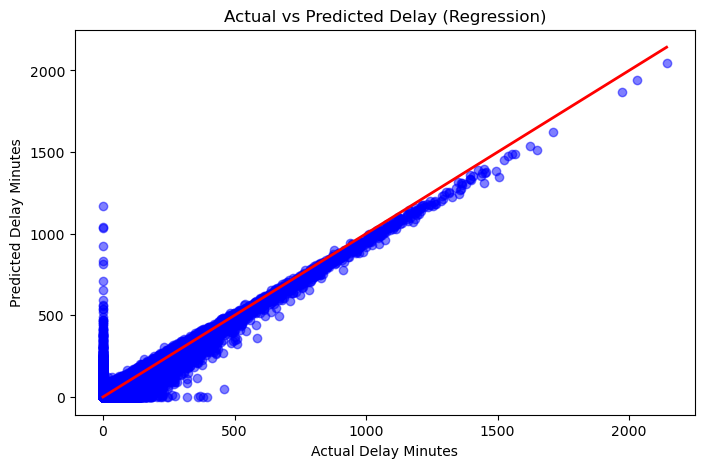

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred, color='blue', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.xlabel("Actual Delay Minutes")
plt.ylabel("Predicted Delay Minutes")
plt.title("Actual vs Predicted Delay (Regression)")
plt.show()